# Tools & Agents 기초

이 노트북에서는 LangChain의 도구(Tools)와 에이전트(Agents) 개념을 학습합니다.
도구는 모델이 외부 세계와 상호작용할 수 있게 해주며, 에이전트는 도구를 사용하여 복잡한 작업을 수행합니다.

**참고**:
- [LangChain 공식 문서 - Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [LangChain 공식 문서 - Agents](https://docs.langchain.com/oss/python/langchain/agents)

**실전 예제**: 이 노트북을 학습한 후 `streamlit-llm_LangChain/060_Agent.py`를 실행해보세요.

## 0. 환경 설정

Colab 등에서 실행 시 필요한 패키지를 설치합니다.
- `langchain` : `create_agent` 등 v1 API (v1.0 이상 필요)
- `langchain-google-genai` : `model_provider="google_genai"` 사용에 필요
- `python-dotenv` : `.env`에서 API 키 로드

로컬에 이미 설치되어 있다면 이 셀은 건너뛰어도 됩니다.

In [9]:
# 필요한 라이브러리 설치 (Colab 등에서 최초 1회 실행)
!pip install -q -U langchain langchain-google-genai python-dotenv

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [21]:
from langchain.chat_models import init_chat_model

# 모델 초기화
model = init_chat_model("gemini-2.5-flash", model_provider="google_genai")
model = init_chat_model("gemini-3.5-flash", model_provider="google_genai")
model

ChatGoogleGenerativeAI(profile={}, google_api_key=SecretStr('**********'), model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x7ce3848aaea0>, default_metadata=(), model_kwargs={})

## Tools & Agents 기초

도구(Tools)와 에이전트(Agents)는 LangChain의 핵심 개념입니다.
도구는 모델이 외부 세계와 상호작용할 수 있게 해주며, 에이전트는 도구를 사용하여 복잡한 작업을 수행합니다.

### 1. 도구 정의 (Tools)

도구(Tools)는 에이전트가 특정 행동을 수행하기 위해 호출하는 구성 요소입니다.
이들은 모델이 명확히 정의된 입력과 출력을 통해 외부 세계와 상호작용할 수 있도록 하여 모델의 기능을 확장합니다.

도구는 호출 가능한 함수(callable function)와 그에 대한 입력 스키마(input schema)를 캡슐화합니다.
이러한 도구들은 호환되는 채팅 모델(chat model)에 전달될 수 있으며, 모델은 도구를 언제, 어떤 인수(argument)로 호출할지 스스로 결정할 수 있습니다.

In [5]:
from langchain.tools import tool

# 가장 간단하게 도구를 만드는 방법은 @tool 데코레이터를 사용하는 것입니다.
# Type hints는 필수입니다. 이들은 도구의 입력 스키마(input schema)를 정의하기 때문입니다.
# 독스트링(docstring)은 모델이 도구의 목적을 이해할 수 있도록 간결하면서도 유용한 정보를 포함해야 합니다.

@tool
def search_db(query: str, limit: int = 10) -> str:
    """검색어(query)에 해당하는 고객 데이터베이스 레코드를 조회합니다.

    Args:
        query: 검색할 키워드 또는 문장
        limit: 반환할 최대 결과 개수
    """
    return f"'{query}'에 대한 검색 결과 {limit}개를 찾았습니다."

# 도구 정보 확인
print("도구 이름:", search_db.name)
print("도구 설명:", search_db.description)

도구 이름: search_db
도구 설명: 검색어(query)에 해당하는 고객 데이터베이스 레코드를 조회합니다.

    Args:
        query: 검색할 키워드 또는 문장
        limit: 반환할 최대 결과 개수


### 2. 도구 속성 사용자 정의

기본적으로 도구의 이름은 함수 이름에서 가져옵니다.
더 설명적인 이름이 필요할 경우에는 이를 재정의(override)할 수 있습니다.
또한, 모델이 도구를 더 명확하게 이해하도록 하기 위해, 자동으로 생성된 도구 설명을 재정의할 수 있습니다.

In [6]:
@tool("calculator", description="산술 계산을 수행합니다. 수학 문제를 풀 때 이 도구를 사용하세요.")
def calc(expression: str) -> str:
    """수학 표현식을 계산합니다."""
    print("\n--- calculator 도구 실행됨 ---")
    try:
        return str(eval(expression))
    except Exception as e:
        return f"계산 오류: {e}"

print("도구 이름:", calc.name)
print("도구 설명:", calc.description)

도구 이름: calculator
도구 설명: 산술 계산을 수행합니다. 수학 문제를 풀 때 이 도구를 사용하세요.


### 3. 고급 스키마 정의

Pydantic 모델이나 JSON 스키마를 사용하여 복잡한 입력을 정의할 수 있습니다.

In [7]:
from pydantic import BaseModel, Field
from langchain_core.tools import tool
import requests

# 입력 데이터 구조 정의 (Pydantic 사용)
class WeatherInput(BaseModel):
    """날씨 질의에 사용할 입력 스키마"""
    latitude: float = Field(description="질의할 지역의 위도를 입력합니다.")
    longitude: float = Field(description="질의할 지역의 경도를 입력합니다.")

# 현재의 온도 가져오기
@tool(args_schema=WeatherInput)
def get_weather(latitude: float, longitude: float) -> str:
    """
    제공된 좌표의 현재 기온을 섭씨(Celsius) 단위로 가져옵니다.
    """
    print('get_weather 도구 호출됨')
    try:
        response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current=temperature_2m")
        data = response.json()
        temp = data['current']['temperature_2m']
        return f"현재 기온: {temp}°C"
    except Exception as e:
        return f"날씨 정보를 가져오는 중 오류 발생: {e}"

# 서울의 위도, 경도로 테스트
print(get_weather.invoke({'latitude': 37.56667, 'longitude': 126.97806}))

get_weather 도구 호출됨
현재 기온: 15.8°C


### 4. ReAct Agent 생성

에이전트(Agents)는 언어 모델과 도구를 결합하여 작업에 대해 추론하고, 사용할 도구를 결정하며, 솔루션을 향해 반복적으로 작업할 수 있는 시스템을 만듭니다.
`create_agent`는 프로덕션에 바로 사용 가능한 에이전트 구현을 제공합니다.
LLM 에이전트는 목표를 달성하기 위해 도구를 반복적으로 실행합니다.

에이전트가 생성되었습니다.
에이전트가 사용할 수 있는 도구: ['search_db', 'calculator', 'get_weather']


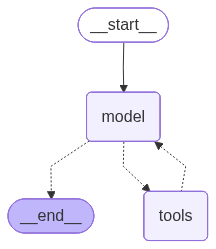

In [22]:
from langchain.agents import create_agent

# 사용 가능한 도구 목록 준비
available_tools = [search_db, calc, get_weather]

# ReAct 에이전트 생성
agent = create_agent(
    model=model,
    tools=available_tools  # Agent가 사용할 도구 목록
)

print("에이전트가 생성되었습니다.")
print(f"에이전트가 사용할 수 있는 도구: {[tool.name for tool in available_tools]}")
agent

### 5. Agent 호출 (Invocation)

에이전트는 State(상태)에 대한 업데이트를 전달하여 호출할 수 있습니다.
모든 에이전트는 상태 안에 메시지들의 시퀀스(sequence of messages)를 포함하고 있으며, 에이전트를 호출하려면 새로운 메시지를 전달하면 됩니다.

In [23]:
# 기본 에이전트 호출 예제
result = agent.invoke(
    {"messages": [
        {'role': 'system', "content": "당신은 도움이 되는 어시스턴트입니다. 주어진 도구를 이용해 답변하세요."},
        {"role": "user", "content": "지금 서울 기온이 몇도인가요?"}
    ]}
)

print("에이전트 응답:")
result['messages'][-1].pretty_print()

get_weather 도구 호출됨
에이전트 응답:
================================== Ai Message ==================================

[{'type': 'text', 'text': '현재 서울의 기온은 15.8°C입니다.', 'extras': {'signature': 'EuABCt0BAQw51sckQlf5R43NH6+qR6CN4VZOWfJoXee4lT7o6dzjnPVEVr0ph5vQ6Z6VzeeEcJtHYxBjbNZTSUlfkHrYSbAeLdSXqnTcb725C7+tnJDEnpaHGT5Lj023Nio72c/g/0CRNIHUh25ETfxzntznBcA3V2q8i26mAgZH/eZ3rKDtdRJUgGwyFs8UJQyCnqELHg0fnYic5807w9L2abqtPGNSYAvJ95r5y0+D4LpQjuGw4LPn+j1a0ygH41ezL/qCR1a25dbJc8MclQ0tP/sUdP6Y8rvK2AwvpiChbhU='}}]


### 7. 시스템 프롬프트 (System prompt)

에이전트가 작업을 수행하는 방식을 제어하려면 시스템 프롬프트(System prompt)를 제공할 수 있습니다.
이때, `system_prompt` 매개변수는 문자열(String) 형태로 지정할 수 있습니다.

In [24]:
agent_with_prompt = create_agent(
    model=model,
    tools=[search_db, calc, get_weather],
    system_prompt="당신은 도움이 되는 어시스턴트입니다. 간결하고 정확하게 답변하세요."
)

result = agent_with_prompt.invoke(
    {"messages": [{"role": "user", "content": "5 더하기 3은?"}]}
)

print("시스템 프롬프트가 적용된 에이전트 응답:")
result['messages'][-1].pretty_print()


--- calculator 도구 실행됨 ---
시스템 프롬프트가 적용된 에이전트 응답:
================================== Ai Message ==================================

[{'type': 'text', 'text': '8입니다.', 'extras': {'signature': 'Em4KbAEMOdbHf027gp3Ar9zlTR0clExVWx1fEdga7Moov6dAabdrfCBOgECpl3tnke3rb2f+LFQB9lVYDAgBqkG5osBUZEhLQusHbmTXs75Y9pmgWz8GlUoaDRDLmdFuIkDYdAJUR+1ZJiB4d6aGww=='}}]


## 주요 포인트 정리

### Tools & Agents
1. **도구 정의**: `@tool` 데코레이터로 간단하게 도구 생성
2. **도구 속성**: 이름과 설명을 사용자 정의하여 모델이 더 잘 이해하도록 함
3. **고급 스키마**: Pydantic 모델을 사용하여 복잡한 입력 정의
4. **내장 도구**: LangChain이 제공하는 다양한 내장 도구 활용 (예: TavilySearch)
5. **에이전트 생성**: `create_agent()`로 도구를 사용하는 에이전트 생성
6. **시스템 프롬프트**: 에이전트의 행동 방식을 제어하는 시스템 프롬프트 설정

**실전 예제**: [streamlit-llm_LangChain/060_Agent.py](streamlit-llm_LangChain/060_Agent.py)에서 Streamlit을 활용한 에이전트 챗봇 구현 예제를 참고하세요.